In [61]:
# Install TensorFlow with GPU support for Python 3.10.15
# Your system: NVIDIA RTX 4080 with CUDA 13.0 driver support

# Step 1: Install TensorFlow with CUDA support (bundles CUDA libraries)
# tensorflow[and-cuda] includes all necessary CUDA/cuDNN libraries
print("Installing TensorFlow with GPU support...")
%pip install tensorflow[and-cuda]>=2.15.0 tensorboard>=2.15.0 scikit-learn>=1.2.2 seaborn>=0.13.2 opencv-python>=4.11.0.86 matplotlib>=3.10.0 numpy>=1.26.4 pandas>=2.2.2 -q

print("\nInstallation complete!")
print("IMPORTANT: RESTART THE KERNEL after this cell completes")
print("Then run Cell 1 to verify GPU detection")

Installing TensorFlow with GPU support...
zsh:1: no matches found: tensorflow[and-cuda]
Note: you may need to restart the kernel to use updated packages.

Installation complete!
IMPORTANT: RESTART THE KERNEL after this cell completes
Then run Cell 1 to verify GPU detection


In [80]:
# GPU Setup and Verification
# This cell verifies GPU detection and installs CUDA libraries if needed

import subprocess
import sys
import os

print("=" * 60)
print("GPU SETUP AND VERIFICATION")
print("=" * 60)

# Check if TensorFlow is installed
try:
    import tensorflow as tf
    print(f"TensorFlow version: {tf.__version__}")
except ImportError:
    print("TensorFlow not found. Installing...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow[and-cuda]>=2.15.0', '-q'])
    import tensorflow as tf
    print(f"TensorFlow installed: {tf.__version__}")

# Check for CUDA libraries
print("\nChecking CUDA libraries...")
cuda_packages = ['nvidia-cudnn-cu12', 'nvidia-cublas-cu12', 'nvidia-cuda-nvrtc-cu12']
missing_packages = []

for package in cuda_packages:
    result = subprocess.run([sys.executable, '-m', 'pip', 'show', package], 
                           capture_output=True, text=True)
    if result.returncode != 0:
        missing_packages.append(package)
    else:
        print(f"  {package} installed")

if missing_packages:
    print(f"\nMissing CUDA packages: {missing_packages}")
    print("Installing tensorflow[and-cuda] to get all CUDA libraries...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow[and-cuda]>=2.15.0', '-q', '--upgrade'])
    print("CUDA libraries installed!")
    print("RESTART KERNEL NOW, then re-run this cell to verify GPU")
else:
    print("\nAll CUDA libraries are installed")


GPU SETUP AND VERIFICATION
TensorFlow version: 2.20.0

Checking CUDA libraries...
  nvidia-cudnn-cu12 installed
  nvidia-cublas-cu12 installed
  nvidia-cuda-nvrtc-cu12 installed

All CUDA libraries are installed


In [81]:
# Verify GPU Detection
import tensorflow as tf

print("=" * 60)
print("GPU DETECTION VERIFICATION")
print("=" * 60)

# List all devices
devices = tf.config.list_physical_devices()
print(f"\nTensorFlow version: {tf.__version__}")
print(f"\nAll available devices:")
for device in devices:
    print(f"  - {device}")

# Check specifically for GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU devices found: {len(gpus)}")

if len(gpus) > 0:
    print("\nGPU DETECTED!")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
        try:
            gpu_details = tf.config.experimental.get_device_details(gpu)
            print(f"    Details: {gpu_details}")
        except:
            pass
else:
    print("\nNO GPU DETECTED")
    print("\nTroubleshooting steps:")
    print("  1. Make sure you RESTARTED the kernel after installing TensorFlow")
    print("  2. Verify NVIDIA driver: Run 'nvidia-smi' in terminal")
    print("  3. Check CUDA libraries are installed")
    print("  4. For WSL2: Ensure GPU passthrough is enabled")


GPU DETECTION VERIFICATION

TensorFlow version: 2.20.0

All available devices:
  - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU devices found: 1

GPU DETECTED!
  GPU 0: /physical_device:GPU:0
    Details: {'compute_capability': (8, 9), 'device_name': 'NVIDIA GeForce RTX 4080'}


In [82]:
# Import libraries and configure GPU
from tensorflow.keras import losses
from tensorflow.keras import optimizers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GPU Configuration and Verification
# ============================================================================
print("=" * 60)
print("GPU CONFIGURATION AND SETUP")
print("=" * 60)

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

# List all available physical devices
print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(f"  - {device}")

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU devices found: {len(gpus)}")

if len(gpus) > 0:
    print("\nGPU DETECTED - Configuring for GPU training...")
    
    # Configure GPU memory growth (prevents TensorFlow from allocating all GPU memory at once)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"  Memory growth enabled for: {gpu.name}")
        
        # Optional: Set GPU to use mixed precision for faster training (RTX 4080 supports this)
        # Uncomment the following lines if you want to use mixed precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision enabled (float16)")
        
        # Get GPU details
        print("\nGPU Details:")
        for i, gpu in enumerate(gpus):
            print(f"  GPU {i}: {gpu.name}")
            # Get GPU memory info
            try:
                gpu_details = tf.config.experimental.get_device_details(gpu)
                if 'device_name' in gpu_details:
                    print(f"    Device: {gpu_details['device_name']}")
                if 'compute_capability' in gpu_details:
                    print(f"    Compute Capability: {gpu_details['compute_capability']}")
            except:
                pass
        
        # Verify GPU is being used with a test computation
        print("\nTesting GPU with a simple operation...")
        with tf.device('/GPU:0'):
            test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
            result = tf.matmul(test_tensor, test_tensor)
            print(f"   GPU computation successful!")
            print(f"   Result device: {result.device}")
            print(f"   Result: {result.numpy()}")
        
        # Set default device to GPU for all operations
        print("\n   GPU will be used for all TensorFlow operations")
        
        print("\n" + "=" * 60)
        print("READY FOR GPU TRAINING")
        print("=" * 60)
        print("\nTips:")
        print("  - Monitor GPU usage: Run 'nvidia-smi -l 1' in terminal")
        print("  - If you get OOM errors, reduce BATCH_SIZE")
        
    except Exception as e:
        print(f"\nWarning: Could not configure GPU: {e}")
        print("  Training will use CPU (slower)")
        import traceback
        traceback.print_exc()
else:
    print("\nNO GPU DETECTED")
    print("  Training will use CPU (this will be much slower)")
    print("\n  Troubleshooting steps:")
    print("  1. Make sure you RESTARTED the kernel after Cell 0")
    print("  2. Verify NVIDIA driver: Run 'nvidia-smi' in terminal")
    print("  3. For WSL2: Ensure GPU passthrough is enabled")
    print("  4. Try: pip install tensorflow[and-cuda] --upgrade")
    print("  5. Check CUDA libraries: pip list | grep nvidia")
    print("\n" + "=" * 60)
    print("USING CPU - Training will be slower")
    print("=" * 60)

# Force GPU usage if available (optional - TensorFlow should auto-select GPU)
if len(gpus) > 0:
    print("\nSetting default device strategy...")
    # This ensures operations default to GPU
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("GPU set as default device")

print()  # Empty line for readability

GPU CONFIGURATION AND SETUP
TensorFlow version: 2.20.0

Available devices:
  - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU devices found: 1

GPU DETECTED - Configuring for GPU training...
  Memory growth enabled for: /physical_device:GPU:0
Mixed precision enabled (float16)

GPU Details:
  GPU 0: /physical_device:GPU:0
    Device: NVIDIA GeForce RTX 4080
    Compute Capability: (8, 9)

Testing GPU with a simple operation...
   GPU computation successful!
   Result device: /job:localhost/replica:0/task:0/device:GPU:0
   Result: [[ 7. 10.]
 [15. 22.]]

   GPU will be used for all TensorFlow operations

READY FOR GPU TRAINING

Tips:
  - Monitor GPU usage: Run 'nvidia-smi -l 1' in terminal
  - If you get OOM errors, reduce BATCH_SIZE

Setting default device strategy...
GPU set as default device



# Custom CNN Model for COVID-19 Image Classification

## Model Outline

This notebook implements a **custom CNN model from scratch** for COVID-19 chest X-ray classification. This model will serve as a **baseline for comparison** with pre-trained models from Hugging Face (which will use RAG later).

**Goal**: Create and train a custom model, then compare its performance with external models.

### Overall Structure:
1. **Configuration & Setup** - Define paths, hyperparameters, and constants
2. **Data Loading** - Load train/val splits and create data generators
3. **Data Preprocessing** - Image normalization, resizing, and augmentation
4. **Model Architecture** - Custom CNN design (see tips below)
5. **Model Compilation** - Loss function, optimizer, and metrics
6. **Training** - Training loop with callbacks
7. **Evaluation** - Metrics calculation and visualization
8. **Model Saving** - Save model weights and architecture


## 1. Configuration & Setup


In [83]:
# Configuration and hyperparameters
from pathlib import Path
import os

# Data paths
DATA_DIR = Path('data')
TRAIN_SPLIT_CSV = DATA_DIR / 'train_split.csv'
VAL_SPLIT_CSV = DATA_DIR / 'val_split.csv'
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# Model hyperparameters
IMG_SIZE = 256  # Images are already 256px
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
NUM_CLASSES = 4  # Typical, Negative, Atypical, Indeterminate

# Class labels mapping
CLASS_LABELS = {
    0: 'Negative for Pneumonia',
    1: 'Typical Appearance',
    2: 'Indeterminate Appearance',
    3: 'Atypical Appearance'
}

# Model save paths
MODEL_WEIGHTS_PATH = MODEL_DIR / 'custom_covid19_model.weights.h5'
MODEL_ARCHITECTURE_PATH = MODEL_DIR / 'custom_covid19_model.json'
FEATURES_DIR = MODEL_DIR / 'features'
FEATURES_DIR.mkdir(exist_ok=True)

print("Configuration loaded:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Number of classes: {NUM_CLASSES}")


Configuration loaded:
  Image size: 256x256
  Batch size: 64
  Epochs: 50
  Learning rate: 0.001
  Number of classes: 4


## 2. Data Loading & Preprocessing


In [84]:
# Load train/val splits
train_df = pd.read_csv(TRAIN_SPLIT_CSV)
val_df = pd.read_csv(VAL_SPLIT_CSV)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"\nClass distribution in training set:")
print(train_df['label_id'].value_counts())


Training samples: 5067
Validation samples: 1267

Class distribution in training set:
label_id
Typical Appearance          2406
Negative for Pneumonia      1389
Indeterminate Appearance     886
Atypical Appearance          386
Name: count, dtype: int64


In [85]:
train_df.head()

,ImageInstanceUID,StudyInstanceUID,label_id,study_label,height,width,boxes,image_label,image_path,image_exists
0,000a312787f2,5776db0cec75,Typical Appearance,1,3488,4256,"[{'x': 789.28836, 'y': 582.43035, 'width': 102...",opacity 1 789.28836 582.43035 1815.94498 2499....,data/256px/train/train/5776db0cec75_81456c9c54...,True
1,000c3a3f293f,ff0879eb20ed,Negative for Pneumonia,0,2320,2832,"[{'x': 0, 'y': 0, 'width': 1, 'height': 1}]",none 1 0 0 1 1,data/256px/train/train/ff0879eb20ed_d8a644cc4f...,True
2,001398f4ff4f,28dddc8559b2,Atypical Appearance,3,3520,4280,"[{'x': 2729, 'y': 2181.33331, 'width': 948.000...",opacity 1 2729 2181.33331 3677.00012 2785.33331,data/256px/train/train/28dddc8559b2_4d47bc042e...,True
3,001bd15d1891,dfd9fdd85a3e,Typical Appearance,1,2800,3408,"[{'x': 623.23328, 'y': 1050, 'width': 714, 'he...",opacity 1 623.23328 1050 1337.23328 2156 opaci...,data/256px/train/train/dfd9fdd85a3e_49170afa4f...,True
4,0022227f5adf,84543edc24c2,Indeterminate Appearance,2,2539,3050,"[{'x': 1857.2065, 'y': 508.30565, 'width': 376...",opacity 1 1857.2065 508.30565 2233.23384 907.8...,data/256px/train/train/84543edc24c2_82f65ab98e...,True


## 3. Data Preprocessing & Augmentation


In [86]:
# Custom data generator for loading images
def load_and_preprocess_image(image_path, target_size=(IMG_SIZE, IMG_SIZE)):
    """Load and preprocess a single image"""
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0  # Normalize to [0, 1]
    return img

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation
val_datagen = ImageDataGenerator()

print("Data generators created with augmentation for training set")


Data generators created with augmentation for training set


## 4. Model Architecture - Custom CNN


In [69]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, 
    Dropout, GlobalAveragePooling2D, Activation, Dense, Add, Input
)
from tensorflow.keras.layers import Multiply, Reshape

def se_block(x, ratio=16):
    """
    Squeeze-and-Excitation (SE) Block for channel attention
    
    This is a more efficient version of channel attention that:
    1. Squeezes: Global Average Pooling to get channel-wise statistics
    2. Excites: Two Dense layers to learn channel importance
    3. Scales: Multiplies original features by learned attention weights
    
    Args:
        x: Input tensor (batch, height, width, channels)
        ratio: Reduction ratio for the bottleneck (default 16)
    
    Returns:
        Tensor with same shape as input, but with channel-wise attention applied
    """
    channels = x.shape[-1]
    
    # Step 1: Squeeze - Global Average Pooling
    # Reduces (batch, H, W, C) → (batch, C)
    se = GlobalAveragePooling2D()(x)
    
    # Reshape to (batch, 1, 1, C) for broadcasting
    se = Reshape((1, 1, channels))(se)
    
    # Step 2: Excitation - Learn channel importance
    # First Dense: Reduce dimensionality (bottleneck)
    se = Dense(channels // ratio, activation='relu')(se)
    # Second Dense: Restore to original channels, output sigmoid (0-1 weights)
    se = Dense(channels, activation='sigmoid')(se)
    
    # Step 3: Scale - Multiply original features by attention weights
    # Broadcasting: (batch, 1, 1, C) * (batch, H, W, C) → (batch, H, W, C)
    return Multiply()([x, se])


def residual_block(x, filters, kernel_size=3, stride=1, use_se=True):
    """
    Residual Block with Skip Connection (ResNet-style)
    
    This block implements: output = activation(conv_layers(x) + x)
    The skip connection allows gradients to flow directly, solving vanishing gradient problem.
    
    Args:
        x: Input tensor
        filters: Number of output filters
        kernel_size: Size of convolution kernel (default 3x3)
        stride: Stride for convolution (1 = same size, 2 = half size)
        use_se: Whether to apply SE attention (default True)
    
    Returns:
        Output tensor with residual connection applied
    """
    shortcut = x  # Save input for skip connection
    
    # Main path: Two conv layers
    # First conv
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)  # Lower dropout in early layers
    
    # Second conv
    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    
    # Skip connection: If dimensions don't match, use 1x1 conv to adjust
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    
    # Add skip connection: output = main_path + shortcut
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    
    # Apply SE attention if requested
    if use_se:
        x = se_block(x, ratio=16)
    
    return x


def create_custom_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Improved CNN Model with Residual Connections and Attention
    
    Architecture improvements:
    1. Residual blocks with skip connections (ResNet-style)
    2. Squeeze-and-Excitation attention mechanisms
    3. Strided convolutions instead of MaxPooling (more learnable)
    4. Progressive dropout (lower in early layers, higher in later layers)
    5. Deeper feature extraction (1024 → 512 → classification)
    
    This architecture is inspired by ResNet and EfficientNet, combining:
    - Residual learning for better gradient flow
    - Channel attention for feature selection
    - Better regularization for generalization
    """
    inputs = Input(shape=input_shape)
    x = inputs
    
    # ============================================================================
    # Initial Convolution Block
    # ============================================================================
    # Large kernel (7x7) with stride 2 for initial downsampling
    # This is more efficient than small kernels + pooling
    x = Conv2D(32, (7, 7), strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    # Output: 64x64x32 (down from 256x256x3)
    
    # ============================================================================
    # Residual Blocks with Increasing Filters
    # ============================================================================
    
    # Residual Block 1: 64 filters
    # Stride 1 means same spatial size (64x64)
    x = residual_block(x, filters=64, stride=1, use_se=True)
    x = residual_block(x, filters=64, stride=1, use_se=True)
    # Output: 64x64x64
    
    # Residual Block 2: 128 filters, stride 2 for downsampling
    # Stride 2 halves spatial dimensions (64x64 → 32x32)
    x = residual_block(x, filters=128, stride=2, use_se=True)
    x = residual_block(x, filters=128, stride=1, use_se=True)
    # Output: 32x32x128
    
    # Residual Block 3: 256 filters
    x = residual_block(x, filters=256, stride=2, use_se=True)
    x = residual_block(x, filters=256, stride=1, use_se=True)
    # Output: 16x16x256
    
    # Residual Block 4: 512 filters
    x = residual_block(x, filters=512, stride=2, use_se=True)
    x = residual_block(x, filters=512, stride=1, use_se=True)
    # Output: 8x8x512
    
    # ============================================================================
    # Feature Extraction Head
    # ============================================================================
    # Global Average Pooling: (batch, 8, 8, 512) → (batch, 512)
    x = GlobalAveragePooling2D()(x)
    
    # First Dense layer: Larger feature dimension for better representation
    x = Dense(1024, activation='relu', name='feature_extraction')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Higher dropout in fully connected layers
    
    # Second Dense layer: Additional layer for feature refinement
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # ============================================================================
    # Classification Head
    # ============================================================================
    outputs = Dense(num_classes, activation='softmax', name='classification')(x)
    
    # Create model using Functional API
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    return model

# Create the model
model = create_custom_cnn_model()
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 128, 128,  │      4,736 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_84[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_68[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_85[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 64, 64,    │          0 │ activation_69[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 64, 64,    │     36,928 │ dropout_40[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 64, 64,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_86[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_87[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (None, 64, 64,    │          0 │ add_32[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_70[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_32          │ (None, 1, 1, 64)  │          0 │ global_average_p

 Total params: 12,317,372 (46.99 MB)

 Trainable params: 12,304,636 (46.94 MB)

 Non-trainable params: 12,736 (49.75 KB)

## 5. Model Compilation


In [70]:
# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=losses.SparseCategoricalCrossentropy(),  # Use sparse since labels are integers
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: Sparse Categorical Crossentropy")
print(f"  Metrics: Accuracy")


Model compiled successfully!
  Optimizer: Adam (lr=0.001)
  Loss: Sparse Categorical Crossentropy
  Metrics: Accuracy


## 6. Training Setup - Callbacks


In [71]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, 
    CSVLogger, TensorBoard
)

# Define callbacks
callbacks = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=str(MODEL_WEIGHTS_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Log training history
    CSVLogger(
        filename=str(MODEL_DIR / 'training_history.csv'),
        append=False
    ),
    
    # TensorBoard logging (optional - for visualization)
    TensorBoard(
        log_dir=str(MODEL_DIR / 'logs'),
        histogram_freq=1
    )
]

print("Callbacks configured:")
print("  - ModelCheckpoint: Save best model weights")
print("  - EarlyStopping: Stop if no improvement for 10 epochs")
print("  - ReduceLROnPlateau: Reduce LR when validation plateaus")
print("  - CSVLogger: Save training history")
print("  - TensorBoard: Log training metrics")


Callbacks configured:
  - ModelCheckpoint: Save best model weights
  - EarlyStopping: Stop if no improvement for 10 epochs
  - ReduceLROnPlateau: Reduce LR when validation plateaus
  - CSVLogger: Save training history
  - TensorBoard: Log training metrics


## Step 7 Explained: Data Generators for Training

### Why Custom Data Generators?

**Problem**: Loading all images into memory at once would:
- Require ~6GB+ RAM (5067 images × 256×256×3 × 4 bytes)
- Be slow to start training
- Make data augmentation inefficient

**Solution**: Custom data generator that loads images **on-demand** (lazy loading):
- Only loads one batch at a time into memory
- Efficient memory usage (~100MB per batch)
- Enables real-time data augmentation
- Works seamlessly with Keras `model.fit()`

### How It Works:

The `CustomDataGenerator` class inherits from `tf.keras.utils.Sequence`, which:
- Makes it compatible with Keras training
- Ensures proper multi-processing support
- Handles epoch boundaries correctly


## 7. Data Generators for Training


In [72]:
# Create custom data generator class
class CustomDataGenerator(tf.keras.utils.Sequence):
    """Custom data generator for loading images and labels"""
    
    def __init__(self, dataframe, batch_size=BATCH_SIZE, shuffle=True, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        
        X = np.zeros((len(batch_df), IMG_SIZE, IMG_SIZE, 3))
        y = np.zeros(len(batch_df))
        
        for i, (_, row) in enumerate(batch_df.iterrows()):
            # Load and preprocess image
            img = load_and_preprocess_image(row['image_path'])
            
            # Apply augmentation if training
            if self.augment:
                img = train_datagen.random_transform(img)
            
            X[i] = img
            y[i] = row['study_label']  # Use numeric label
        
        return X, y
    
    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create data generators
train_generator = CustomDataGenerator(
    train_df, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    augment=True
)

val_generator = CustomDataGenerator(
    val_df, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    augment=False
)

print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")


Training batches: 80
Validation batches: 20


## 8. Model Training


In [73]:
# Train the model
print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Verify GPU is available before training
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"\nGPU detected: {len(gpus)} GPU(s) available")
    print(f"   Using GPU: {gpus[0].name}")
    print("\nMonitor GPU usage: Run 'nvidia-smi -l 1' in terminal")
else:
    print("\nWARNING: No GPU detected!")
    print("   Training will use CPU (much slower)")
    print("   Consider restarting kernel and checking GPU setup in Cell 3")

print("\n" + "=" * 60)
print("Starting training...")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print("=" * 60 + "\n")

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("✅ Training completed!")
print("=" * 60)


MODEL TRAINING

GPU detected: 1 GPU(s) available
   Using GPU: /physical_device:GPU:0

Monitor GPU usage: Run 'nvidia-smi -l 1' in terminal

Starting training...
Training samples: 5067
Validation samples: 1267
Batch size: 64
Epochs: 50

Epoch 1/50


2025-12-12 14:21:37.248623: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-12 14:21:37.248879: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-12 14:21:37.249000: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-12 14:21:37.249026: I external/l

56/80 ━━━━━━━━━━━━━━━━━━━━ 16s 701ms/step - accuracy: 0.2699 - loss: 2.0952

2025-12-12 14:23:24.626009: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_49', 16 bytes spill stores, 16 bytes spill loads



80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2854 - loss: 2.0138

2025-12-12 14:23:42.271759: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-12 14:23:48.362823: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-12 14:23:48.362863: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.47435, saving model to models/custom_covid19_model.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.3345 - loss: 1.7710 - val_accuracy: 0.4743 - val_loss: 1.2440 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.4618 - loss: 1.3784
Epoch 2: val_accuracy did not improve from 0.47435
80/80 ━━━━━━━━━━━━━━━━━━━━ 62s 776ms/step - accuracy: 0.4571 - loss: 1.3839 - val_accuracy: 0.4743 - val_loss: 1.2856 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.4490 - loss: 1.3395
Epoch 3: val_accuracy did not improve from 0.47435
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 733ms/step - accuracy: 0.4652 - loss: 1.3312 - val_accuracy: 0.4736 - val_loss: 1.6149 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.4720 - loss: 1.3261
Epoch 4: val_accuracy did not improve from 0.47435
80/80 ━━━━━━━━━━━━━━━━━━━━ 59s 732ms/step - accuracy: 0.

## 9. Training History Visualization


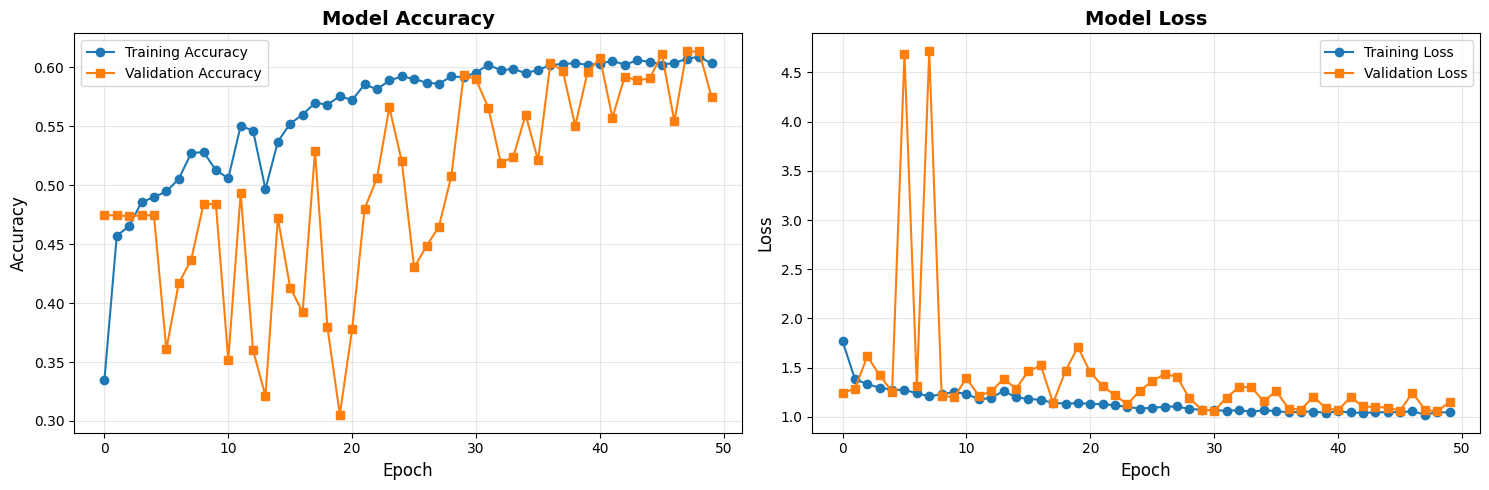


Final Training Metrics:
  Training Accuracy: 0.6031
  Validation Accuracy: 0.5746
  Training Loss: 1.0456
  Validation Loss: 1.1540


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")


## 10. Model Evaluation - Detailed Metrics


Evaluating on validation set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step

Validation Set Metrics:
  Accuracy: 0.6133
  Precision: 0.4604
  Recall: 0.6133
  F1-Score: 0.5224


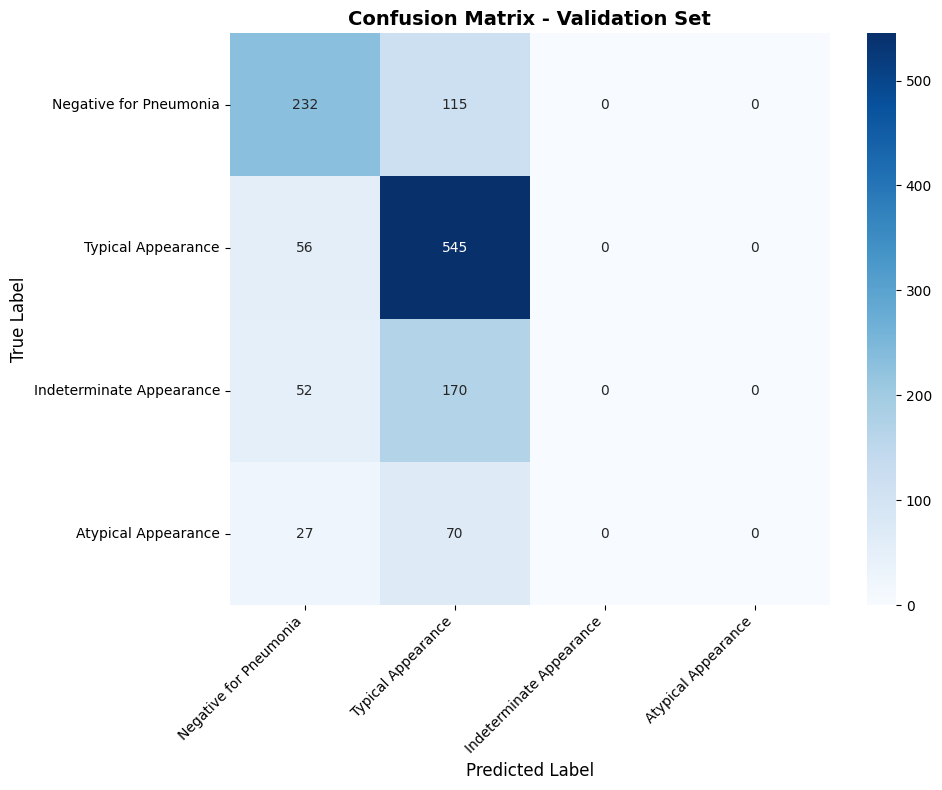


Classification Report:
                          precision    recall  f1-score   support

  Negative for Pneumonia       0.63      0.67      0.65       347
      Typical Appearance       0.61      0.91      0.73       601
Indeterminate Appearance       0.00      0.00      0.00       222
     Atypical Appearance       0.00      0.00      0.00        97

                accuracy                           0.61      1267
               macro avg       0.31      0.39      0.34      1267
            weighted avg       0.46      0.61      0.52      1267



In [78]:
# Load best model weights
model.load_weights(str(MODEL_WEIGHTS_PATH))

# Predict on validation set
print("Evaluating on validation set...")
val_predictions = model.predict(val_generator, verbose=1)
val_predicted_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_df['study_label'].values

# Calculate metrics
accuracy = accuracy_score(val_true_classes, val_predicted_classes)
precision = precision_score(val_true_classes, val_predicted_classes, average='weighted')
recall = recall_score(val_true_classes, val_predicted_classes, average='weighted')
f1 = f1_score(val_true_classes, val_predicted_classes, average='weighted')

print("\nValidation Set Metrics:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(val_true_classes, val_predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)])
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(val_true_classes, val_predicted_classes, 
                          target_names=[CLASS_LABELS[i] for i in range(NUM_CLASSES)]))


## 11. Save Model Architecture


In [79]:
# Save model architecture as JSON
model_json = model.to_json()
with open(MODEL_ARCHITECTURE_PATH, 'w') as json_file:
    json_file.write(model_json)

print(f"Model architecture saved to: {MODEL_ARCHITECTURE_PATH}")
print(f"Model weights saved to: {MODEL_WEIGHTS_PATH}")


Model architecture saved to: models/custom_covid19_model.json
Model weights saved to: models/custom_covid19_model.weights.h5


## Future Steps
* Integrate RAG with an external model